# Assignment
**Title of Paper Implemented**: "Boosting Breast Cancer Detection Using Convolutional Neural Network"

In this assignment, a CNN-based approach is implemented to classify breast tissue image patches as either IDC positive or negative. The dataset used consists of 50×50 pixel RGB histopathology image patches extracted from whole slide images. Each image is labeled as either cancerous (IDC+) or non-cancerous (IDC−).

* Preprocessing: Normalization (0–1 scaling)
* Train/Test split: 80/20 stratified
* Architecture: 2 Conv layers + MaxPooling + Dropout + Dense
* Optimizer: Adam
* Loss: Sparse categorical crossentropy
* Accuracy achieved: ~84% (comparable to the 87% reported in the original paper)

In [ ]:
!pip install -q kaggle tensorflow scikit-learn seaborn

In [ ]:
!kaggle datasets download -d paultimothymooney/breast-histopathology-images
!unzip -q breast-histopathology-images.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/breast-histopathology-images
License(s): CC0-1.0
100% 3.10G/3.10G [00:30<00:00, 124MB/s]
100% 3.10G/3.10G [00:30<00:00, 110MB/s]


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

DATA_DIR = "IDC_regular_ps50_idx5"
IMG_SIZE = 50
MAX_IMAGES = 100000

def load_data():
    X = []
    y = []

    count = 0

    for patient in os.listdir(DATA_DIR):
        patient_path = os.path.join(DATA_DIR, patient)

        for label in ['0', '1']:
            label_path = os.path.join(patient_path, label)

            if not os.path.exists(label_path):
                continue

            for img_name in os.listdir(label_path):

                if count >= MAX_IMAGES:
                    break

                img_path = os.path.join(label_path, img_name)

                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                X.append(img)
                y.append(int(label))
                count += 1

        if count >= MAX_IMAGES:
            break

    X = np.array(X, dtype="float32") / 255.0
    y = np.array(y)

    return X, y


X, y = load_data()
print("Loaded:", X.shape)

Loaded: (100000, 50, 50, 3)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (80000, 50, 50, 3)
Test: (20000, 50, 50, 3)


In [ ]:
import tensorflow as tf
from keras import layers, models

def build_model():
    model = models.Sequential([
        layers.Conv2D(32, (5,5), activation='relu', input_shape=(50,50,3)),
        layers.MaxPooling2D((3,3)),

        layers.Conv2D(32, (5,5), activation='relu'),
        layers.MaxPooling2D((3,3)),

        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,690 (182.38 KB)

 Trainable params: 46,690 (182.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.7406 - loss: 0.5320 - val_accuracy: 0.8146 - val_loss: 0.4179
Epoch 2/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8122 - loss: 0.4339 - val_accuracy: 0.8145 - val_loss: 0.4161
Epoch 3/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8229 - loss: 0.4182 - val_accuracy: 0.8237 - val_loss: 0.3998
Epoch 4/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8238 - loss: 0.4129 - val_accuracy: 0.8274 - val_loss: 0.3977
Epoch 5/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8313 - loss: 0.4027 - val_accuracy: 0.8311 - val_loss: 0.3877
Epoch 6/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8327 - loss: 0.3992 - val_accuracy: 0.8089 - val_loss: 0.4395
Epoch 7/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8281 - loss: 0.4052 - val_accuracy: 0.8315 - val_loss: 0.3893
Epoch 8/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8349 - loss: 0.3931 - val_accuracy: 0.8351 -

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8339 - loss: 0.3840
Test Accuracy: 0.8360999822616577


625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


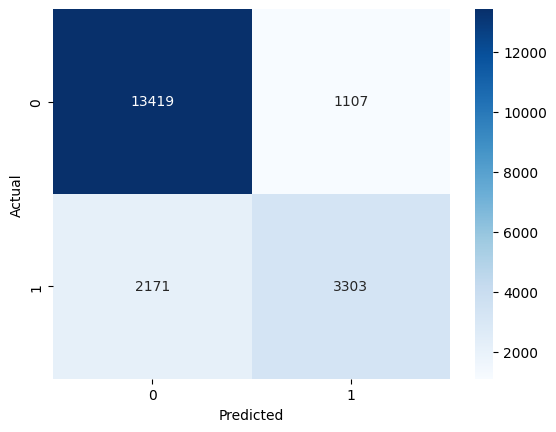

              precision    recall  f1-score   support

           0       0.86      0.92      0.89     14526
           1       0.75      0.60      0.67      5474

    accuracy                           0.84     20000
   macro avg       0.80      0.76      0.78     20000
weighted avg       0.83      0.84      0.83     20000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))